# Sales Prediction — Dataset Audit & Exploratory Data Analysis

**CodSoft Data Science Internship — Task 4: Sales Prediction Using Python**
(local folder `Task2_Sales_Prediction`, my own project numbering)

**Phase 1 only.** This notebook audits the raw dataset and explores it. No model is trained,
no value is imputed, no row is dropped and nothing is written back to the raw data file.

---
## 1. Project Objective

The CodSoft task statement describes the problem as:

> Sales prediction involves forecasting the amount of a product that customers will purchase, taking into
> account various factors such as advertising expenditure, target audience segmentation, and advertising
> platform selection.

The goal of this phase is to analyse the historical advertising/sales data and understand the relationships
between the available explanatory variables and sales **before** building any prediction model.

A note on scope, so that nothing is claimed that the data does not support: the task statement mentions
*target audience segmentation* and *advertising platform selection*. This dataset contains per-platform
advertising budgets (TV, Radio, Newspaper) and the corresponding sales figure. It therefore supports the
*advertising expenditure* and *platform* aspects. It contains **no** audience, demographic, geographic or
time information, so audience segmentation cannot be studied here. That is a property of the dataset, not
an omission in the analysis.

---
## 2. Dataset Source

The dataset is the one the CodSoft source document links to, traced end to end:

| | |
|---|---|
| **CodSoft source document** | `DATA SCIENCE.pdf`, page 9 — "TASK 4 · SALES PREDICTION USING PYTHON · DATASET CLICK HERE" |
| **Link behind "CLICK HERE"** | `https://www.kaggle.com/code/ashydv/sales-prediction-simple-linear-regression/input` |
| **That link's target** | the *input* tab of the Kaggle notebook `ashydv/sales-prediction-simple-linear-regression` |
| **Data source of that notebook** | Kaggle dataset `ashydv/advertising-dataset` (read from the notebook's own metadata field `datasetDataSources`) |
| **Dataset URL** | https://www.kaggle.com/datasets/ashydv/advertising-dataset |
| **Download endpoint used** | `https://www.kaggle.com/api/v1/datasets/download/ashydv/advertising-dataset` |
| **File in the archive** | `advertising.csv` |
| **Stored at** | `dataset/advertising.csv` |
| **Download date** | 2026-09-20 |
| **File size** | 4,062 bytes |
| **SHA-256** | `137f755ad6fd3bc6471085f7631a2fba6c04cb8acd71eaf5cc9af6839d43fdd5` |
| **Shape** | 200 rows × 4 columns |
| **Origin of the data** | the *Advertising* dataset used in *An Introduction to Statistical Learning* (ISLR), as the source notebook itself states |

**Verification.** The downloaded file was checked against the saved outputs of the source notebook
(`sales-prediction-simple-linear-regression.ipynb`) before being used: shape `(200, 4)`, the same first five
rows, and an identical `describe()` table. No substitute dataset was used.

The raw file is treated as read-only for the whole project. Section 18 re-computes its checksum at the end
of this notebook to show that the audit did not alter it.

---
## 3. Imports and Configuration

In [1]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42  # fixed for any sampling used for display purposes

print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)

pandas 3.0.6 | numpy 2.5.3 | seaborn 0.13.2


### Repository-relative paths

Paths are resolved from the notebook's own location, so the notebook runs from anywhere in the repository
and contains no absolute Windows paths.

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR if (NOTEBOOK_DIR / "dataset").is_dir() else NOTEBOOK_DIR.parent

DATASET_PATH = PROJECT_DIR / "dataset" / "advertising.csv"
VIZ_DIR = PROJECT_DIR / "visualizations"
VIZ_DIR.mkdir(exist_ok=True)

print("project directory:", PROJECT_DIR.name)
print("dataset file     :", DATASET_PATH.relative_to(PROJECT_DIR))
print("dataset exists   :", DATASET_PATH.is_file())

project directory: Task2_Sales_Prediction
dataset file     : dataset\advertising.csv
dataset exists   : True


---
## 4. Load Raw Dataset

The file is read exactly as it is on disk — no `dtype` overrides, no `na_values`, no index column, no
renaming. Everything below describes the raw file.

In [3]:
df = pd.read_csv(DATASET_PATH)

print(f"shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"columns: {list(df.columns)}")

shape: 200 rows x 4 columns
columns: ['TV', 'Radio', 'Newspaper', 'Sales']


In [4]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1000,37.8000,69.2000,22.1000
1,44.5000,39.3000,45.1000,10.4000
2,17.2000,45.9000,69.3000,12.0000
3,151.5000,41.3000,58.5000,16.5000
4,180.8000,10.8000,58.4000,17.9000


In [5]:
df.tail()

,TV,Radio,Newspaper,Sales
195,38.2000,3.7000,13.8000,7.6000
196,94.2000,4.9000,8.1000,14.0000
197,177.0000,9.3000,6.4000,14.8000
198,283.6000,42.0000,66.2000,25.5000
199,232.1000,8.6000,8.7000,18.4000


In [6]:
df.dtypes.to_frame("dtype")

,dtype
TV,float64
Radio,float64
Newspaper,float64
Sales,float64


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


**Observation.** Four columns, all read as `float64`, 200 rows, and a plain `RangeIndex` — the file carries
no identifier column, no date column and no text column.

---
## 5. Dataset Schema

In [8]:
schema = pd.DataFrame({
    "Column": df.columns,
    "Data Type": [str(t) for t in df.dtypes],
    "Non-null Count": df.notna().sum().to_numpy(),
    "Missing Count": df.isna().sum().to_numpy(),
    "Unique Values": [df[c].nunique(dropna=True) for c in df.columns],
    "Min": [df[c].min() for c in df.columns],
    "Max": [df[c].max() for c in df.columns],
})
schema

,Column,Data Type,Non-null Count,Missing Count,Unique Values,Min,Max
0,TV,float64,200,0,190,0.7000,296.4000
1,Radio,float64,200,0,167,0.0000,49.6000
2,Newspaper,float64,200,0,172,0.3000,114.0000
3,Sales,float64,200,0,121,1.6000,27.0000


### Column meanings

These descriptions come from the dataset's own structure and from the source notebook's problem statement
("predict sales based on the money spent on different platforms for marketing"). Nothing beyond that is
asserted — the file ships without a data dictionary, and the monetary unit is not stated anywhere in the
source.

| Column | Meaning as supported by the source | Unit |
|---|---|---|
| `TV` | advertising budget spent on the TV platform for a marketing campaign | not stated in the source (ISLR uses thousands of dollars) |
| `Radio` | advertising budget spent on the Radio platform | same, not stated |
| `Newspaper` | advertising budget spent on the Newspaper platform | same, not stated |
| `Sales` | the sales figure recorded for that campaign — the quantity to be predicted | not stated (ISLR uses thousands of units) |

Each row is one observation (one market/campaign) pairing three platform budgets with the resulting sales.
The rows carry no label, no order key and no timestamp, so the data is **cross-sectional, not a time
series** — there is no chronological ordering to exploit or to respect when splitting later.

---
## 6. Target Variable Identification

The target was not assumed in advance; it follows from the task statement and from the dataset itself.

**`TARGET = "Sales"`**

Evidence:

1. The CodSoft task asks to *forecast the amount of a product that customers will purchase*. `Sales` is the
   only column that measures an amount purchased.
2. The other three columns (`TV`, `Radio`, `Newspaper`) are all advertising spend per platform — they are
   exactly the "advertising expenditure" and "advertising platform selection" inputs the task names.
3. The source notebook this dataset is attached to states the same: predict `Sales` from the money spent on
   the different platforms.
4. Structurally, the three spend columns are plausible *inputs* a business controls, while `Sales` is the
   *outcome* it observes afterwards.

The three spend columns are therefore the candidate predictors, and no column derived from `Sales` exists
in the file — so there is nothing target-derived available to be used as a feature (checked in section 17).

In [9]:
TARGET = "Sales"
FEATURES = [c for c in df.columns if c != TARGET]

print("TARGET  :", TARGET)
print("FEATURES:", FEATURES)

TARGET  : Sales
FEATURES: ['TV', 'Radio', 'Newspaper']


---
## 7. Missing Value Audit

No imputation is done in this phase — this section only measures.

In [10]:
missing = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().sum() / len(df) * 100).round(4),
})
missing

,Missing Count,Missing %
TV,0,0.0000
Radio,0,0.0000
Newspaper,0,0.0000
Sales,0,0.0000


In [11]:
total_missing = int(df.isna().sum().sum())
print(f"total missing cells : {total_missing}")
print(f"rows with any NaN   : {int(df.isna().any(axis=1).sum())}")

if total_missing == 0:
    print("\nNo missing values anywhere in the dataset.")
    print("No chart saved as 01_missing_values.png: a missingness chart of an all-zero matrix would be")
    print("misleading rather than informative. The finding is reported in the table above instead.")
else:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
    sns.barplot(x=pct.to_numpy(), y=pct.index.to_numpy(), ax=ax, color="#4C72B0")
    ax.set_title("Missing values by column")
    ax.set_xlabel("Missing (% of rows)")
    ax.set_ylabel("Column")
    fig.savefig(VIZ_DIR / "01_missing_values.png")
    plt.show()

total missing cells : 0
rows with any NaN   : 0

No missing values anywhere in the dataset.
No chart saved as 01_missing_values.png: a missingness chart of an all-zero matrix would be
misleading rather than informative. The finding is reported in the table above instead.


**Finding.** The dataset is complete: 0 missing cells out of 800. Nothing needs imputing in Phase 2, and no
missingness chart was produced because there is no missingness to show.

An additional check for values that are technically present but stand in for "missing" (empty strings,
sentinel codes such as `-1` or `999`) is done in section 9.

---
## 8. Duplicate Audit

Duplicates are **reported, not removed**. The decision belongs to Phase 2.

In [12]:
exact_dupes = df.duplicated(keep=False)
print(f"exact duplicate rows (all 4 columns)      : {int(exact_dupes.sum())}")

feature_dupes = df.duplicated(subset=FEATURES, keep=False)
print(f"duplicated on the 3 spend columns only    : {int(feature_dupes.sum())}")

target_dupes = df.duplicated(subset=[TARGET], keep=False)
print(f"rows sharing a Sales value with another row: {int(target_dupes.sum())}"
      f"  ({df[TARGET].nunique()} distinct Sales values in {len(df)} rows)")

exact duplicate rows (all 4 columns)      : 0
duplicated on the 3 spend columns only    : 0
rows sharing a Sales value with another row: 133  (121 distinct Sales values in 200 rows)


In [13]:
if exact_dupes.any():
    display(df[exact_dupes].sort_values(FEATURES))
else:
    print("No exact duplicate rows to display.")

No exact duplicate rows to display.


**Finding.** There are no exact duplicate rows and no rows sharing an identical combination of the three
spend values. Every observation is therefore distinct as a feature vector.

Repeated values within a *single* column do occur (`Sales` has fewer distinct values than rows because it is
rounded to one decimal place), but that is value granularity, not record duplication. No action is needed,
and in particular there is no duplicate-record risk of the same observation landing on both sides of a
future train/test split.

---
## 9. Numeric Feature Analysis

All four columns are numeric; the three predictors are analysed here and the target in section 11.

In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("numeric columns    :", numeric_cols)
print("categorical columns:", categorical_cols if categorical_cols else "none")

numeric columns    : ['TV', 'Radio', 'Newspaper', 'Sales']
categorical columns: none


In [15]:
summary = df[numeric_cols].describe().T
summary["median"] = df[numeric_cols].median()
summary["skew"] = df[numeric_cols].skew()
summary["kurtosis"] = df[numeric_cols].kurtosis()
summary = summary[["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max", "skew", "kurtosis"]]
summary

,count,mean,median,std,min,25%,50%,75%,max,skew,kurtosis
TV,200.0000,147.0425,149.7500,85.8542,0.7000,74.3750,149.7500,218.8250,296.4000,-0.0699,-1.2265
Radio,200.0000,23.2640,22.9000,14.8468,0.0000,9.9750,22.9000,36.5250,49.6000,0.0942,-1.2604
Newspaper,200.0000,30.5540,25.7500,21.7786,0.3000,12.7500,25.7500,45.1000,114.0000,0.8947,0.6495
Sales,200.0000,15.1305,16.0000,5.2839,1.6000,11.0000,16.0000,19.0500,27.0000,-0.0737,-0.6401


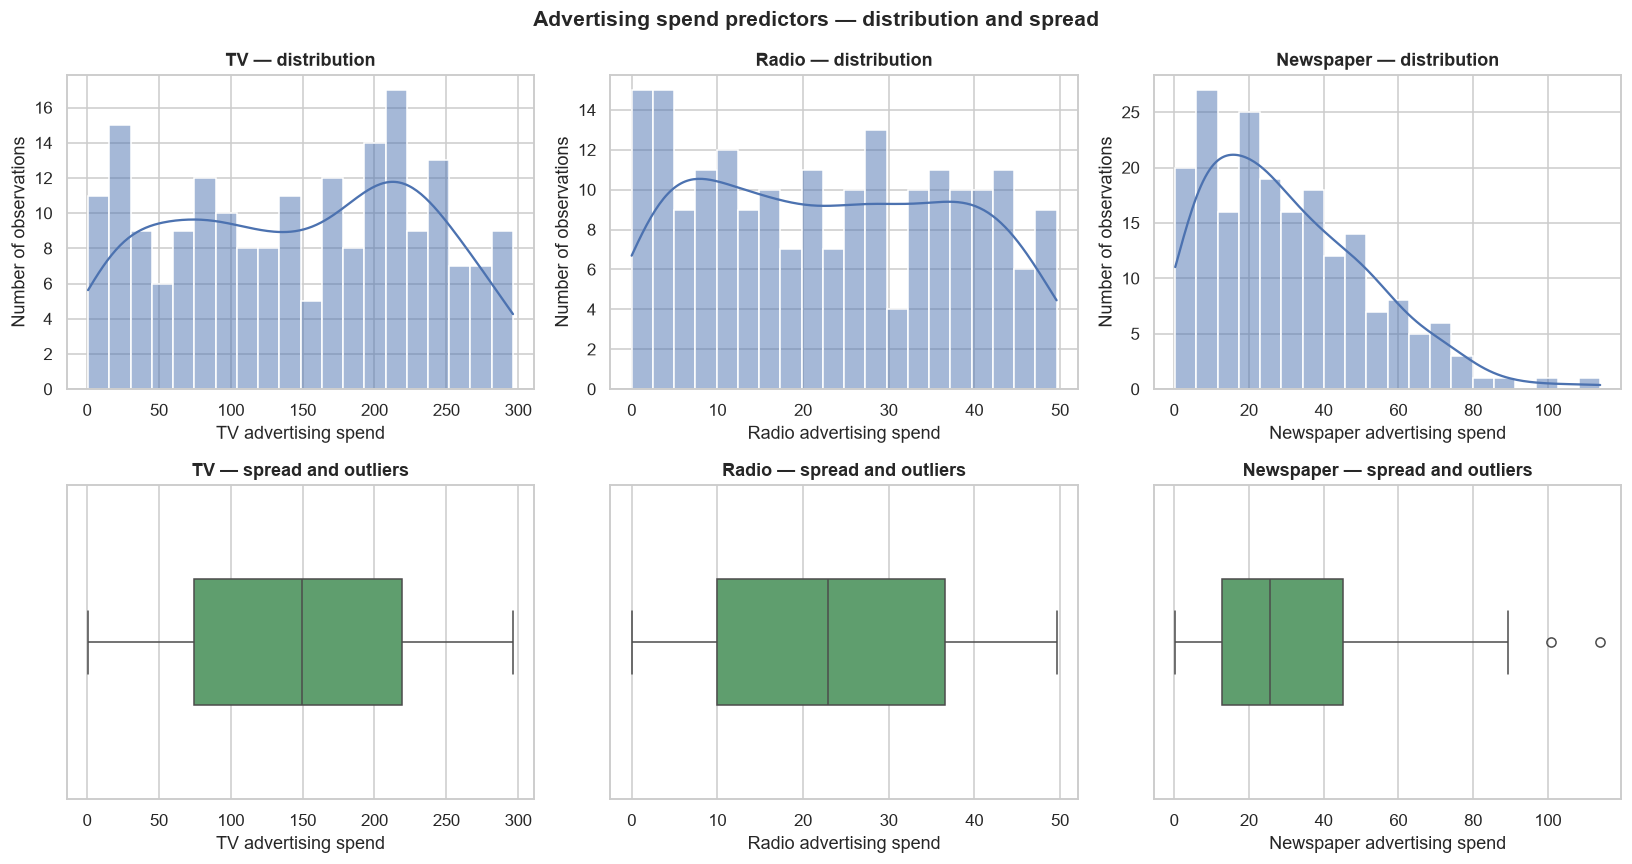

In [16]:
fig, axes = plt.subplots(2, len(FEATURES), figsize=(5 * len(FEATURES), 8))
for i, col in enumerate(FEATURES):
    sns.histplot(df[col], kde=True, ax=axes[0, i], color="#4C72B0", bins=20)
    axes[0, i].set_title(f"{col} — distribution")
    axes[0, i].set_xlabel(f"{col} advertising spend")
    axes[0, i].set_ylabel("Number of observations")

    sns.boxplot(x=df[col], ax=axes[1, i], color="#55A868", width=0.4)
    axes[1, i].set_title(f"{col} — spread and outliers")
    axes[1, i].set_xlabel(f"{col} advertising spend")

fig.suptitle("Advertising spend predictors — distribution and spread", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

### Suspicious-value checks

Checking for the things that quietly break a model later: negatives, exact zeros, sentinel codes and
constant columns.

In [17]:
checks = pd.DataFrame({
    "negative values": [(df[c] < 0).sum() for c in numeric_cols],
    "exact zeros": [(df[c] == 0).sum() for c in numeric_cols],
    "distinct values": [df[c].nunique() for c in numeric_cols],
    "is constant": [df[c].nunique() <= 1 for c in numeric_cols],
    "is near-constant (top value > 95%)": [
        (df[c].value_counts(normalize=True).iloc[0] > 0.95) for c in numeric_cols
    ],
    "sentinel-like (-1 / -999 / 999)": [df[c].isin([-1, -999, 999]).sum() for c in numeric_cols],
}, index=numeric_cols)
checks

,negative values,exact zeros,distinct values,is constant,is near-constant (top value > 95%),sentinel-like (-1 / -999 / 999)
TV,0,0,190,False,False,0
Radio,0,1,167,False,False,0
Newspaper,0,0,172,False,False,0
Sales,0,0,121,False,False,0


In [18]:
zero_rows = df[(df[FEATURES] == 0).any(axis=1)]
print(f"rows where at least one platform budget is exactly 0: {len(zero_rows)}")
display(zero_rows)

rows where at least one platform budget is exactly 0: 1


,TV,Radio,Newspaper,Sales
127,80.2000,0.0000,9.2000,11.9000


**Findings.**

- **`TV`** — spend ranges from 0.7 to 296.4, mean 147.04, median 149.75. Close to symmetric
  (skew ≈ −0.07) and fairly flat across its range; the box plot shows no points beyond the whiskers.
- **`Radio`** — ranges 0.0 to 49.6, mean 23.26, median 22.90, skew ≈ 0.09. Also near-symmetric, no
  whisker outliers.
- **`Newspaper`** — ranges 0.3 to 114.0, mean 30.55, median 25.75, skew ≈ 0.89. The only visibly
  **right-skewed** predictor, with a long upper tail and a small number of high-spend points beyond the
  upper whisker.
- **No negative values** anywhere, which is what one would expect of an advertising budget.
- **One exact zero**, in `Radio`. A campaign with no radio spend is a legitimate business scenario rather
  than a data error, so it is kept and noted.
- **No constant or near-constant column**, and no sentinel-looking codes (`-1`, `999`, `-999`).
- No column has so few distinct values that it should be treated as categorical.

Nothing is removed or transformed here.

---
## 10. Categorical Feature Analysis

In [19]:
if categorical_cols:
    for col in categorical_cols:
        print(f"--- {col} ---")
        print(f"unique categories: {df[col].nunique()}")
        display(df[col].value_counts(dropna=False).to_frame("count"))
else:
    print("The dataset contains no categorical (non-numeric) columns.")
    print("All 4 columns are continuous float64 measurements, so there is nothing to analyse in this")
    print("section and no frequency plot would be meaningful. Nothing to encode in Phase 2.")

The dataset contains no categorical (non-numeric) columns.
All 4 columns are continuous float64 measurements, so there is nothing to analyse in this
section and no frequency plot would be meaningful. Nothing to encode in Phase 2.


**Finding.** There are no categorical variables. All four columns are continuous numeric measurements, so
there is no cardinality, rare-category or category-missingness question in this dataset, and no encoding
step will be needed in Phase 2. Section 14 is therefore also not applicable.

---
## 11. Target Distribution

`Sales` is described here. It is **not** transformed.

In [20]:
target_stats = pd.Series({
    "count": df[TARGET].count(),
    "mean": df[TARGET].mean(),
    "median": df[TARGET].median(),
    "std": df[TARGET].std(),
    "min": df[TARGET].min(),
    "25%": df[TARGET].quantile(0.25),
    "50%": df[TARGET].quantile(0.50),
    "75%": df[TARGET].quantile(0.75),
    "max": df[TARGET].max(),
    "IQR": df[TARGET].quantile(0.75) - df[TARGET].quantile(0.25),
    "skewness": df[TARGET].skew(),
    "kurtosis": df[TARGET].kurtosis(),
}).to_frame("Sales")
target_stats

,Sales
count,200.0000
mean,15.1305
median,16.0000
std,5.2839
min,1.6000
25%,11.0000
50%,16.0000
75%,19.0500
max,27.0000
IQR,8.0500


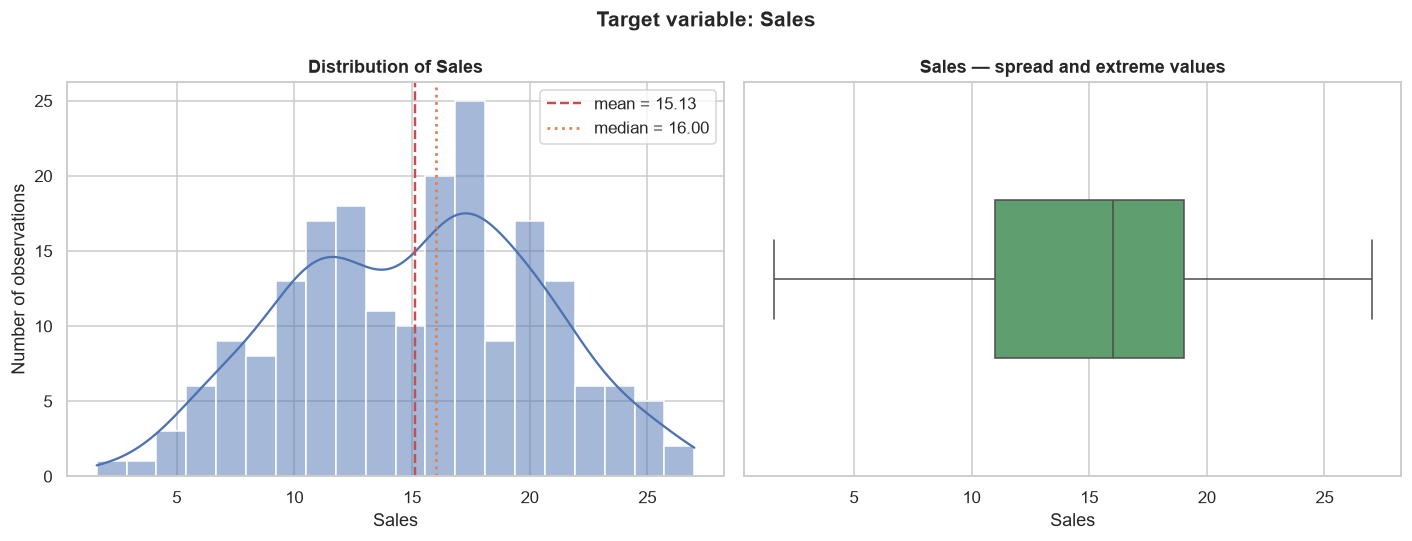

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df[TARGET], bins=20, kde=True, ax=axes[0], color="#4C72B0")
axes[0].axvline(df[TARGET].mean(), color="#C44E52", linestyle="--", linewidth=1.6,
                label=f"mean = {df[TARGET].mean():.2f}")
axes[0].axvline(df[TARGET].median(), color="#DD8452", linestyle=":", linewidth=1.8,
                label=f"median = {df[TARGET].median():.2f}")
axes[0].set_title("Distribution of Sales")
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("Number of observations")
axes[0].legend()

sns.boxplot(x=df[TARGET], ax=axes[1], color="#55A868", width=0.4)
axes[1].set_title("Sales — spread and extreme values")
axes[1].set_xlabel("Sales")

fig.suptitle("Target variable: Sales", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "02_sales_distribution.png")
plt.show()

**Finding.** `Sales` ranges from 1.6 to 27.0 with mean 15.13 and median 16.00, standard deviation 5.28.

The distribution is **close to symmetric**: skewness is −0.074, so only a very slight lean towards the
lower tail, with the mean (15.13) sitting a little below the median (16.00). Kurtosis is negative (−0.64),
meaning the distribution is **flatter** than a normal one rather than heavy-tailed — sales are spread fairly
evenly across the 11–20 region instead of clustering tightly around a peak. The box plot shows no points
beyond the whiskers, so no observation is extreme by that criterion.

A target transformation (log or similar) is therefore **not** indicated: there is no skew worth correcting.
Nothing is transformed here in any case; the question is recorded for Phase 2, where the answer on this
evidence is "not needed".

---
## 12. Feature vs Sales Relationships

Each advertising platform is examined individually against `Sales`. A fitted line is shown as a visual aid
to the trend; it is not a model and nothing is being trained here.

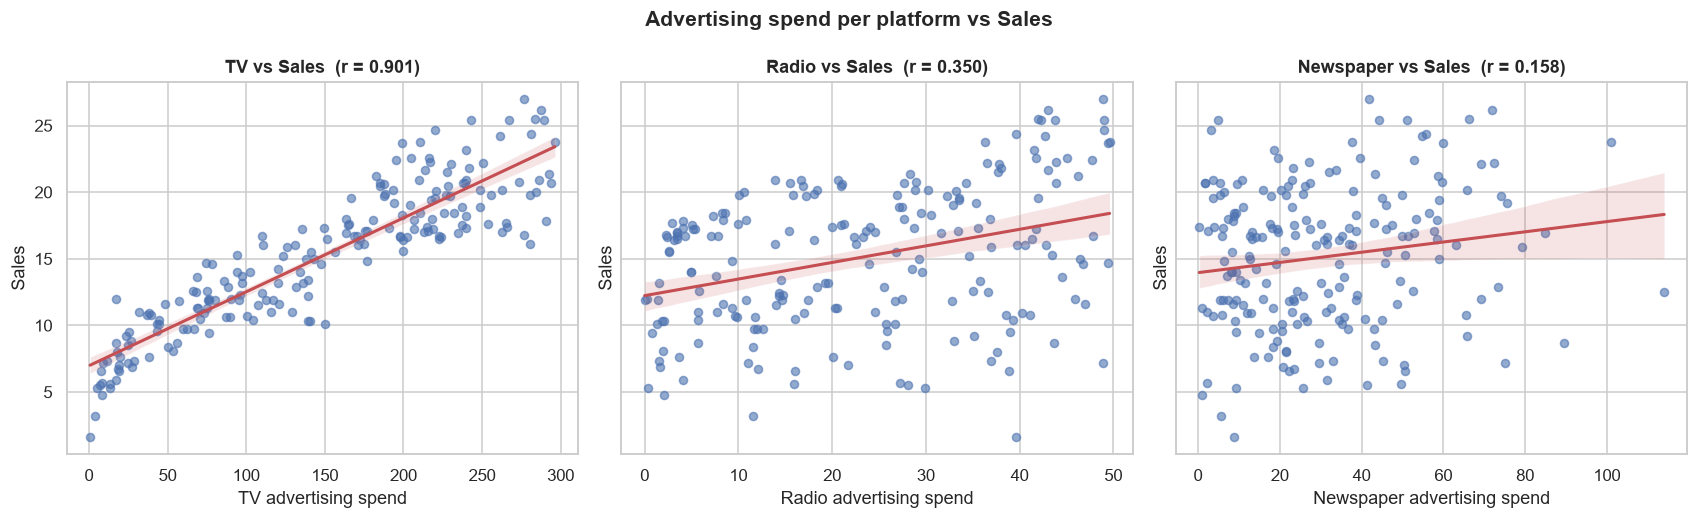

In [22]:
fig, axes = plt.subplots(1, len(FEATURES), figsize=(5.2 * len(FEATURES), 4.8), sharey=True)
for ax, col in zip(axes, FEATURES):
    sns.regplot(data=df, x=col, y=TARGET, ax=ax,
                scatter_kws={"alpha": 0.6, "s": 28, "color": "#4C72B0"},
                line_kws={"color": "#C44E52", "linewidth": 2})
    r = df[col].corr(df[TARGET])
    ax.set_title(f"{col} vs Sales  (r = {r:.3f})")
    ax.set_xlabel(f"{col} advertising spend")
axes[0].set_ylabel("Sales")

fig.suptitle("Advertising spend per platform vs Sales", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "03_feature_vs_sales.png")
plt.show()

In [23]:
rel = pd.DataFrame({
    "Pearson r with Sales": [df[c].corr(df[TARGET]) for c in FEATURES],
    "Spearman rho with Sales": [df[c].corr(df[TARGET], method="spearman") for c in FEATURES],
}, index=FEATURES).sort_values("Pearson r with Sales", ascending=False)
rel

,Pearson r with Sales,Spearman rho with Sales
TV,0.9012,0.9010
Radio,0.3496,0.3399
Newspaper,0.1580,0.1230


**Findings** — stated as associations, not causes. Nothing here establishes that spending more on a platform
*causes* higher sales; the data is observational, budgets were set by someone for reasons not recorded, and
no experiment is involved.

- **`TV` is strongly associated with `Sales`** (r ≈ 0.90). The scatter shows a clear, close-to-linear upward
  pattern. It is by some distance the strongest single relationship in the data — which is exactly why the
  source notebook picked `TV` for its simple linear regression.
- **`Radio` shows a moderate positive relationship** (r ≈ 0.35). The pattern is real but the spread around
  it is wide, so `Radio` alone explains little; it may still contribute meaningfully alongside `TV`.
- **`Newspaper` appears to have a weak relationship** (r ≈ 0.16). The point cloud is close to shapeless.
  Whether it carries any information once `TV` and `Radio` are accounted for is an open question for Phase 2,
  not something to conclude now.
- The `TV` scatter also hints at **non-constant variance** — the vertical spread of `Sales` looks narrower at
  low `TV` spend than at high `TV` spend. Worth re-checking on residuals once a model exists.

No feature is dropped on the basis of a weak correlation at this stage.

---
## 13. Correlation Analysis

In [24]:
corr = df[numeric_cols].corr()
corr

,TV,Radio,Newspaper,Sales
TV,1.0000,0.0548,0.0566,0.9012
Radio,0.0548,1.0000,0.3541,0.3496
Newspaper,0.0566,0.3541,1.0000,0.1580
Sales,0.9012,0.3496,0.1580,1.0000


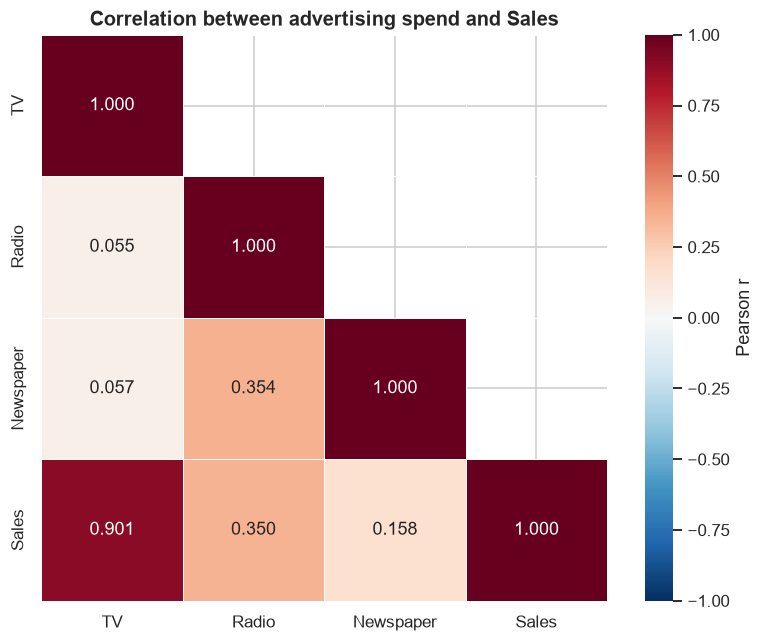

In [25]:
fig, ax = plt.subplots(figsize=(7.5, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.6, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation between advertising spend and Sales", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "04_correlation_heatmap.png")
plt.show()

In [26]:
pred_corr = corr.loc[FEATURES, FEATURES]
pairs = [
    (a, b, pred_corr.loc[a, b])
    for i, a in enumerate(FEATURES) for b in FEATURES[i + 1:]
]
pd.DataFrame(pairs, columns=["Feature A", "Feature B", "Pearson r"]).sort_values(
    "Pearson r", key=lambda s: s.abs(), ascending=False
)

,Feature A,Feature B,Pearson r
2,Radio,Newspaper,0.3541
1,TV,Newspaper,0.0566
0,TV,Radio,0.0548


**Findings.**

*Correlation with the target:* `TV` 0.901, `Radio` 0.350, `Newspaper` 0.158. The ordering is unambiguous.

*Correlation between predictors:* all three pairs are weak — the strongest is `Radio`–`Newspaper` at
r ≈ 0.354, with `TV`–`Radio` ≈ 0.055 and `TV`–`Newspaper` ≈ 0.057. There is therefore **no serious
multicollinearity**: the three budgets vary largely independently of one another, so a linear model's
coefficients should be reasonably stable and individually interpretable. A VIF check in Phase 2 would be a
cheap confirmation, but nothing here suggests a problem.

Correlation measures linear association only, and association is not causation. A high `TV` correlation does
not license a statement that TV advertising drives sales — only that higher TV budgets are observed together
with higher sales in this data.

No feature is removed at this stage.

---
## 14. Categorical Feature vs Sales

In [27]:
if categorical_cols:
    fig, axes = plt.subplots(1, len(categorical_cols), figsize=(6 * len(categorical_cols), 5))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, categorical_cols):
        sns.boxplot(data=df, x=col, y=TARGET, ax=ax)
        ax.set_title(f"Sales by {col}")
        ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(VIZ_DIR / "05_sales_by_category.png")
    plt.show()
else:
    print("Not applicable: the dataset contains no categorical predictors (see section 10).")
    print("05_sales_by_category.png was deliberately not created — a category plot with no categories")
    print("would be an empty chart produced only to satisfy a filename.")

Not applicable: the dataset contains no categorical predictors (see section 10).
05_sales_by_category.png was deliberately not created — a category plot with no categories
would be an empty chart produced only to satisfy a filename.


**Not applicable.** With no categorical columns in the file, there are no groups to compare sales across, so
`05_sales_by_category.png` was not created.

---
## 15. Outlier Analysis

Potential outliers are **identified and counted only**. Nothing is removed or capped in Phase 1 — that
decision belongs to Phase 2, and on this dataset the likely decision is to keep them.

In [28]:
def iqr_outliers(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - k * iqr, q3 + k * iqr
    mask = (series < low) | (series > high)
    return mask, low, high


rows = []
outlier_masks = {}
for col in numeric_cols:
    mask, low, high = iqr_outliers(df[col])
    outlier_masks[col] = mask
    rows.append({
        "Column": col,
        "Lower bound": low,
        "Upper bound": high,
        "Outliers (count)": int(mask.sum()),
        "Outliers (% of rows)": round(mask.sum() / len(df) * 100, 2),
        "Below lower": int((df[col] < low).sum()),
        "Above upper": int((df[col] > high).sum()),
    })
outlier_table = pd.DataFrame(rows)
outlier_table

,Column,Lower bound,Upper bound,Outliers (count),Outliers (% of rows),Below lower,Above upper
0,TV,-142.3000,435.5000,0,0.0000,0,0
1,Radio,-29.8500,76.3500,0,0.0000,0,0
2,Newspaper,-35.7750,93.6250,2,1.0000,0,2
3,Sales,-1.0750,31.1250,0,0.0000,0,0


In [29]:
any_outlier = pd.DataFrame(outlier_masks).any(axis=1)
print(f"rows flagged as an outlier in at least one column: {int(any_outlier.sum())} "
      f"({any_outlier.sum() / len(df) * 100:.2f}% of 200 rows)")

if any_outlier.any():
    display(df[any_outlier])

rows flagged as an outlier in at least one column: 2 (1.00% of 200 rows)


,TV,Radio,Newspaper,Sales
16,67.8000,36.6000,114.0000,12.5000
101,296.4000,36.3000,100.9000,23.8000


In [30]:
z = (df[numeric_cols] - df[numeric_cols].mean()) / df[numeric_cols].std(ddof=0)
z_flags = (z.abs() > 3).sum()
print("values beyond 3 standard deviations, by column:")
print(z_flags.to_string())

values beyond 3 standard deviations, by column:
TV           0
Radio        0
Newspaper    2
Sales        0


**Findings.**

- Only **`Newspaper`** contains IQR-flagged points: **2 rows (1.0% of the dataset)**, both above the upper
  bound of ≈ 93.6, at newspaper budgets of 114.0 and 100.9.
- `TV`, `Radio` and `Sales` contain **no** IQR-flagged values at all.
- The z-score check (|z| > 3, population standard deviation) flags the **same 2 `Newspaper` values** and
  nothing else, so the two criteria agree exactly on which points are unusual and on which columns are clean.

Interpretation: these are two unusually large newspaper budgets, not implausible or corrupt values. They sit
within a realistic range for the column, and with only 200 rows, discarding real observations costs more than
it gains. **Nothing is removed here**, and the recommendation carried into Phase 2 is to keep them and,
if anything, check their influence on the fitted model rather than delete them up front.

---
## 16. Data Quality Findings

| Aspect | Finding |
|---|---|
| **Shape** | 200 rows × 4 columns |
| **Missing values** | none — 0 of 800 cells |
| **Duplicate rows** | none — 0 exact duplicates, 0 duplicated feature combinations |
| **Data types** | all 4 columns `float64`; no type correction needed |
| **Numerical variables** | `TV`, `Radio`, `Newspaper` (predictors) and `Sales` (target) |
| **Categorical variables** | none |
| **ID / index columns** | none — the file carries no identifier column |
| **Constant / near-constant columns** | none |
| **Negative values** | none |
| **Suspicious / sentinel values** | none; a single legitimate `Radio = 0.0` (a campaign with no radio spend) |
| **Outliers** | 2 rows (1.0%), both high `Newspaper` budgets (114.0 and 100.9); flagged by both the IQR and the 3-sd criteria; no other column flags anything |
| **Target characteristics** | `Sales` 1.6–27.0, mean 15.13, median 16.00, sd 5.28, near-symmetric (skew −0.07), flat-topped (kurtosis −0.64), no extreme values |
| **Strongest association with target** | `TV` (r = 0.901), then `Radio` (0.350), then `Newspaper` (0.158) |
| **Multicollinearity** | not a concern — highest predictor pair is `Radio`–`Newspaper` at r ≈ 0.354 |
| **Overall** | a small, clean, complete, well-behaved dataset requiring no repair before modelling |

---
## 17. Initial Modeling Considerations

**No model is trained in this phase.** These are the considerations Phase 1 raises for Phase 2, each one
tied to something actually observed above.

**Not needed for this dataset:**

- *Missing-value handling* — there are none (section 7).
- *Categorical encoding* — there are no categorical columns (section 10).
- *Duplicate removal* — there are none (section 8).
- *Type conversion* — every column is already numeric.
- *Target transformation* — skew is −0.07, i.e. the target is already near-symmetric (section 11).

**Worth considering:**

- **Feature scaling.** Not required for ordinary least squares or tree-based models, but it does matter for
  regularised regression (Ridge/Lasso) and distance-based models (KNN, SVR). `TV` spans 0.7–296.4 while
  `Radio` spans 0–49.6, so any such model should have scaling fitted **inside** a pipeline on training folds
  only, never on the full dataset.
- **Train/test split strategy.** The data is cross-sectional with no time or group column, so a plain random
  split is appropriate — no chronological split and no grouped split is required. With only 200 rows a single
  hold-out set is small and noisy, so **k-fold cross-validation** (e.g. 5-fold) on the training portion should
  carry the model comparison, with a held-out test set reserved for the final number only. Fix the random
  seed for reproducibility.
- **Model family.** The `TV` relationship looks close to linear, so linear regression is a sensible baseline.
  Whether interaction terms (e.g. `TV × Radio`) or non-linear models improve on it is an empirical question
  for Phase 2, not an assumption to build in now.
- **Possible non-constant variance.** The `TV` vs `Sales` scatter suggests the spread of `Sales` widens at
  higher `TV` spend (section 12). Check the residual plot in Phase 2 before trusting any interval estimates.
- **`Newspaper`'s contribution.** Weak on its own (r = 0.158) but correlated with `Radio` (r = 0.354). Decide
  its fate by measured validation performance, not by its raw correlation.
- **The two `Newspaper` outliers.** Keep them, but check their influence (e.g. Cook's distance) on a fitted
  linear model.
- **Baseline.** Establish a mean-predictor baseline in Phase 2 so that every model's improvement is measured
  against something rather than reported in isolation.
- **Metrics.** `Sales` is continuous and has no zeros, so MAE, RMSE and R² are all usable; report all three.

### Data leakage audit

Checked explicitly, before any modelling:

| Risk | Status |
|---|---|
| A feature derived from `Sales` (ratio, share, rank, running total) | **None.** Only three columns exist besides the target, all of them advertising budgets, none computed from `Sales`. Verified below. |
| A feature containing future information | **None.** The data is cross-sectional — no dates, no ordering, no post-campaign measurements. All three predictors are budgets, which are set *before* sales are observed. |
| An ID / index column used as a predictor | **None.** The file has no identifier column; the index is a plain `RangeIndex` created at load time and is not a feature. It must not be passed to a model, and `FEATURES` excludes it by construction. |
| A column that should clearly be excluded | **None** on leakage grounds. `Newspaper` may be dropped later for weak signal, which is a modelling choice, not a leakage fix. |
| Duplicate observations crossing a train/test boundary | **No risk.** Zero duplicate rows and zero duplicated feature combinations, so no observation can appear on both sides of a split. |
| Preprocessing fitted on the full dataset | **The live risk for Phase 2.** Nothing has been fitted here, and nothing must be: any scaler or transformer has to be fitted inside a pipeline on training folds only. |
| Model selection on the test set | **The other live risk.** Use cross-validation for comparison; touch the test set once, at the end. |

Nothing has been modified. This section records findings only.

In [31]:
# Sanity check for the "feature derived from Sales" risk: a column derived from the target would
# typically show a near-perfect linear or ratio relationship with it.
leak = pd.DataFrame({
    "Pearson r with Sales": [df[c].corr(df[TARGET]) for c in FEATURES],
    "|r| > 0.98 (suspicious)": [abs(df[c].corr(df[TARGET])) > 0.98 for c in FEATURES],
    "constant ratio to Sales": [np.isclose((df[c] / df[TARGET]).std(), 0) for c in FEATURES],
}, index=FEATURES)
display(leak)
print("\nNo predictor is a deterministic function of Sales.")
print("Columns passed to a model in Phase 2:", FEATURES, "-> target:", TARGET)

,Pearson r with Sales,|r| > 0.98 (suspicious),constant ratio to Sales
TV,0.9012,False,False
Radio,0.3496,False,False
Newspaper,0.1580,False,False



No predictor is a deterministic function of Sales.
Columns passed to a model in Phase 2: ['TV', 'Radio', 'Newspaper'] -> target: Sales


---
## 18. Raw Data Protection

The raw file must stay byte-for-byte identical. Its checksum is re-computed here, at the end of the audit,
and compared with the value recorded at download time in section 2.

In [32]:
EXPECTED_SHA256 = "137f755ad6fd3bc6471085f7631a2fba6c04cb8acd71eaf5cc9af6839d43fdd5"
EXPECTED_BYTES = 4062

raw = DATASET_PATH.read_bytes()
actual_sha256 = hashlib.sha256(raw).hexdigest()

print("file    :", DATASET_PATH.relative_to(PROJECT_DIR))
print("size    :", len(raw), "bytes")
print("sha-256 :", actual_sha256)
print()
print("size matches    :", len(raw) == EXPECTED_BYTES)
print("checksum matches:", actual_sha256 == EXPECTED_SHA256)

assert actual_sha256 == EXPECTED_SHA256, "Raw dataset has changed since download!"
print("\nRaw dataset is unchanged. This notebook read it only; it never wrote to dataset/.")

file    : dataset\advertising.csv
size    : 4062 bytes
sha-256 : 137f755ad6fd3bc6471085f7631a2fba6c04cb8acd71eaf5cc9af6839d43fdd5

size matches    : True
checksum matches: True

Raw dataset is unchanged. This notebook read it only; it never wrote to dataset/.


---
## Phase 1 Summary

The dataset referenced by CodSoft Task 4 was traced to Kaggle dataset `ashydv/advertising-dataset`, downloaded
unmodified, and verified against the source notebook's own saved outputs. It holds **200 rows × 4 columns**:
three advertising budgets (`TV`, `Radio`, `Newspaper`) and the target, **`Sales`**.

The data is complete, free of duplicates, entirely numeric, and contains no leakage risk within the file
itself. `TV` shows much the strongest association with `Sales` (r = 0.901), `Radio` a moderate one (0.350)
and `Newspaper` a weak one (0.158), with no meaningful multicollinearity between the predictors. The only
flagged anomalies are two high `Newspaper` budgets (1% of rows), which are plausible and were kept.

**No model was trained, no value was imputed, no row was removed and the raw file is unchanged.**
Modelling begins in Phase 2.